We develop a Real NVP normalizing flow with an MLP sampler at the latent space and train it on DNA atomic coordinates obtained from AMBER-based molecular dynamics simulations. The notebook was initially designed for Google Colab, therefore some dependency installation and runtime configuration steps are Colab-oriented and should be adjusted for non-Colab environments.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1


In [2]:
!pip install netCDF4
!pip install parmed
!pip install openmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for parmed: filename=ParmEd-4.3.0-cp312-cp312-linux_x86_64.whl size=19471505 sha256=946438b38187d55aa9b5e213ac4875017f568df8e2400bb0d13a339f13853a55
  Stored in directory: /root/.cache/pip/wheels/a3/c6/57/3ff4e09a91685738568d531ee739797913dd13b3553e202234
Successfully built parmed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 16.0 MB/s eta 0:00:00


In [3]:
import os
import re
import tqdm
import json
import time
import netCDF4
import numpy as np
import parmed as pmd
from tqdm import tqdm

import math
import pickle
import argparse
from sys import exit
from sklearn import datasets
import matplotlib.pyplot as plt

import openmm
from openmm import app, openmm
from openmm import unit, LangevinIntegrator
from openmm.app import AmberPrmtopFile, Simulation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


The DNA coordinates and simulation box information were generated with AMBER and are already pre-processed. The processed dataset is stored in all_traj_DNAonly.npz.

In [5]:
data = np.load("all_traj_DNAonly.npz")

coords = data["coords"]
boxes  = data["boxes"]

print("coords shape:", coords.shape)
print("boxes shape :", boxes.shape)

coords shape: (8050, 1894, 3)
boxes shape : (8050, 3)


Once the trajectory data are loaded, we calculate the DNA extension for every frame using the coordinate list (e.g., an end-to-end measure derived from selected atoms). These per-frame extension values are then used to train the MLP sampler for the latent space of the Real NVP model after training.

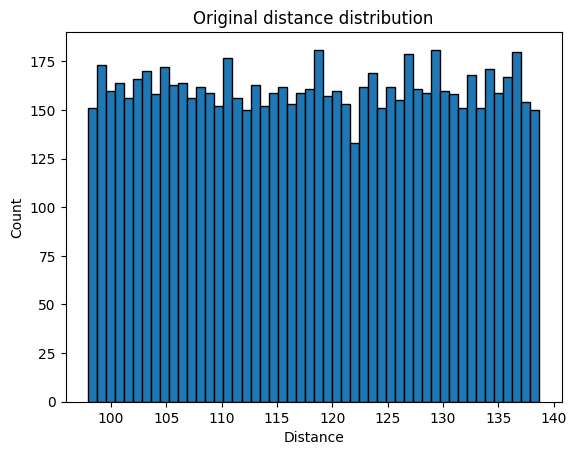

In [6]:
p1, p2, p3, p4 = 30, 943, 946, 1871

def middlePoint(one, two):
    return (one + two) / 2.0

def dist(one, two):
    return math.sqrt(np.sum((one - two)**2))

def compute_distances(trajectories, p1, p2, p3, p4):
    distances = []
    for coords in trajectories:
        leftEnd  = middlePoint(coords[p1], coords[p4])
        rightEnd = middlePoint(coords[p2], coords[p3])
        distances.append(dist(leftEnd, rightEnd))
    return torch.tensor(distances, dtype=torch.float32).unsqueeze(1)

distances_orig = compute_distances(coords, p1, p2, p3, p4)

plt.hist(distances_orig.numpy(), bins=50, edgecolor='black')
plt.title("Original distance distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

Final pre-processing consists of:

*   Flattening: each coordinate frame is reshaped into a single vector size D.
*   Normalization (inputs): we compute the per-dimension mean and standard deviation across the full dataset and standardize the flattened coordinates.
*   Normalization (MLP input): we likewise standardize the extension length values, which will be used as the MLP sampler inputs.

The resulting tensors train_x (normalized flattened coordinates) and train_c (normalized MLP inputs) are then used for model training.

In [7]:
coords_np = coords.astype(np.float32)
coords_flat = coords_np.reshape(8050, -1)
coords_flat = torch.from_numpy(coords_flat)
D = coords_flat.shape[1]
print("Flattened dimension D:", D)

Flattened dimension D: 5682


In [8]:
x_train_full = coords_flat
x_mean = x_train_full.mean(dim=0, keepdim=True)
x_std  = x_train_full.std(dim=0, keepdim=True) + 1e-6

x_all_norm = (coords_flat - x_mean) / x_std


In [9]:
c_all = distances_orig
c_train_full = c_all
c_mean = c_train_full.mean(dim=0, keepdim=True)
c_std  = c_train_full.std(dim=0, keepdim=True) + 1e-6

c_all_norm = (c_all - c_mean) / c_std


In [10]:
train_x = x_all_norm
train_c = c_all_norm

print("train_x:", train_x.shape, "train_c:", train_c.shape)

train_x: torch.Size([8050, 5682]) train_c: torch.Size([8050, 1])


We build the data loader and set the batch size to 16.

In [11]:
batch_size = 16

train_ds = TensorDataset(train_x)
train_loader = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True, drop_last=True)

We define the Real NVP affine coupling layer. A binary mask selects which input dimensions stay fixed. The fixed part is passed through a small neural network to predict scale and shift values, which are applied to the remaining dimensions. The layer returns both the transformed output and the log-determinant term needed for maximum-likelihood training, and it also includes an analytic inverse() for mapping back to the original space.

In [12]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim, mask):
        super().__init__()
        self.dim = dim
        self.register_buffer("mask", mask.float())

        input_dim = dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim * 2),
        )

    def forward(self, x):
        m = self.mask.to(x.device)
        x_masked = x * m

        inp = x_masked
        s, t = self.net(inp).chunk(2, dim=1)
        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        y = x_masked + (1 - m) * (x * scale + t)
        logdet = ((1 - m) * s).sum(dim=1)
        return y, logdet

    def inverse(self, y):
        m = self.mask.to(y.device)
        y_masked = y * m

        inp = y_masked
        s, t = self.net(inp).chunk(2, dim=1)

        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        x = y_masked + (1 - m) * ((y - t) / scale)
        logdet = -((1 - m) * s).sum(dim=1)
        return x, logdet


We now build the Real NVP model by stacking multiple affine coupling layers with alternating masks. In the forward pass, the model transforms data x into latent variables z and accumulates the total log-determinant across layers. In the inverse pass, we apply the layers in reverse order to map z back to x, which is used for sampling new structures.

In [13]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=6, hidden_dim=512):
        super().__init__()
        self.dim = dim

        masks = []
        for i in range(n_layers):
            mask = torch.zeros(dim)
            mask[i % 2 :: 2] = 1.0
            masks.append(mask)

        self.layers = nn.ModuleList([
            CouplingLayer(dim, hidden_dim, masks[i])
            for i in range(n_layers)
        ])

    def forward(self, x):
        logdet_sum = torch.zeros(x.shape[0], device=x.device)
        z = x
        for layer in self.layers:
            z, logdet = layer(z)
            logdet_sum += logdet
        return z, logdet_sum

    def inverse(self, z):
        logdet_sum = torch.zeros(z.shape[0], device=z.device)
        x = z
        for layer in reversed(self.layers):
            x, logdet = layer.inverse(x)
            logdet_sum += logdet
        return x, logdet_sum


We initialise the Real NVP model and the Adam optimiser.

In [14]:
model = RealNVP(dim=D, n_layers=6, hidden_dim=512).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

We define the negative log-likelihood (NLL) loss for the flow and train the model. For each batch, we transform the input coordinates x into latent variables z, assume a standard normal prior over z, and combine this with the log-determinant from the coupling layers to compute the log-likelihood of x. We then minimize the average NLL using backpropagation for 200 epochs, recording the training loss each epoch.

In [15]:
def flow_nll(model, x):
    z, logdet = model(x)
    log_pz = -0.5 * torch.sum(z**2, dim=1)
    log_px = log_pz + logdet
    nll = -log_px.mean()
    return nll

n_epochs = 200
train_losses = []
for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)

        optimizer.zero_grad()
        loss = flow_nll(model, x_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    print(f"Epoch {epoch:03d} | train NLL: {train_loss:.4f}")


Epoch 001 | train NLL: -1769.8437
Epoch 002 | train NLL: -4559.3969
Epoch 003 | train NLL: -5552.3451
Epoch 004 | train NLL: -6156.9452
Epoch 005 | train NLL: -6630.0021
Epoch 006 | train NLL: -7011.3193
Epoch 007 | train NLL: -7348.0472
Epoch 008 | train NLL: -7626.8725
Epoch 009 | train NLL: -7848.2346
Epoch 010 | train NLL: -8096.9648
Epoch 011 | train NLL: -8282.3046
Epoch 012 | train NLL: -8467.0700
Epoch 013 | train NLL: -8618.8068
Epoch 014 | train NLL: -8780.1372
Epoch 015 | train NLL: -8905.8007
Epoch 016 | train NLL: -9046.5946
Epoch 017 | train NLL: -9197.9079
Epoch 018 | train NLL: -9272.9846
Epoch 019 | train NLL: -9415.4923
Epoch 020 | train NLL: -9506.4508
Epoch 021 | train NLL: -9616.2139
Epoch 022 | train NLL: -9701.3328
Epoch 023 | train NLL: -9783.8715
Epoch 024 | train NLL: -9890.5481
Epoch 025 | train NLL: -9960.5161
Epoch 026 | train NLL: -10022.8902
Epoch 027 | train NLL: -10116.7297
Epoch 028 | train NLL: -10150.0739
Epoch 029 | train NLL: -10272.5429
Epoch 030 

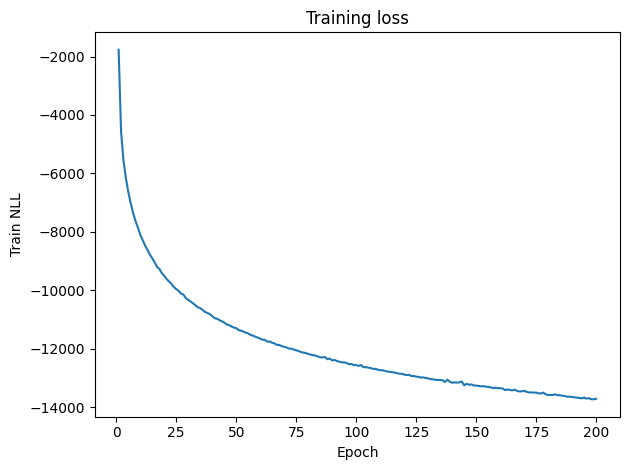

In [16]:
plt.figure()
plt.plot(range(1, n_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train NLL")
plt.title("Training loss")
plt.tight_layout()
plt.show()

We switch the trained flow to evaluation mode and pass the training data through it to obtain the corresponding latent representations z. We then build a DataLoader containing pairs of condition values (train_c) and their matching latent vectors (z). This dataset can be used later to learn or analyse a mapping between the condition and the latent space.

In [17]:
model.eval()

with torch.no_grad():
    z, _ = model(train_x.to(device))
    z = z.cpu()

z_tensor = z.clone()
print("z_tensor shape:", z_tensor.shape)


z_tensor shape: torch.Size([8050, 5682])


In [18]:
cond_tensor = train_c.cpu()
from torch.utils.data import TensorDataset, DataLoader
map_ds = TensorDataset(cond_tensor, z_tensor)
map_loader = DataLoader(map_ds, batch_size=64, shuffle=True)

We now define the MLP regression model that takes the (normalized) condition value (a single scalar) as input and predicts the corresponding latent vector z of dimension D. We use mean squared error (MSE) as the loss and train the network with the Adam optimizer.

In [19]:
D = z_tensor.shape[1]

mlp = nn.Sequential(
    nn.Linear(1, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, D)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

We then train the MLP for 80 epochs. For each batch, the network predicts a latent vector z from the condition value c, and we minimize the MSE between the prediction and the true z. We record the average loss per epoch and print progress every 10 epochs.

In [20]:
epochs = 80
train_losses_mlp = []
for epoch in range(epochs):
    mlp.train()
    epoch_loss = 0.0

    for c_batch, z_batch in map_loader:
        c_batch = c_batch.to(device)
        z_batch = z_batch.to(device)

        optimizer.zero_grad()
        outputs = mlp(c_batch)
        loss = criterion(outputs, z_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * c_batch.size(0)

    epoch_loss /= len(map_loader.dataset)
    train_losses_mlp.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}")

Epoch [10/80], Loss: 0.789219
Epoch [20/80], Loss: 0.784431
Epoch [30/80], Loss: 0.779984
Epoch [40/80], Loss: 0.777141
Epoch [50/80], Loss: 0.774746
Epoch [60/80], Loss: 0.772931
Epoch [70/80], Loss: 0.771238
Epoch [80/80], Loss: 0.769715


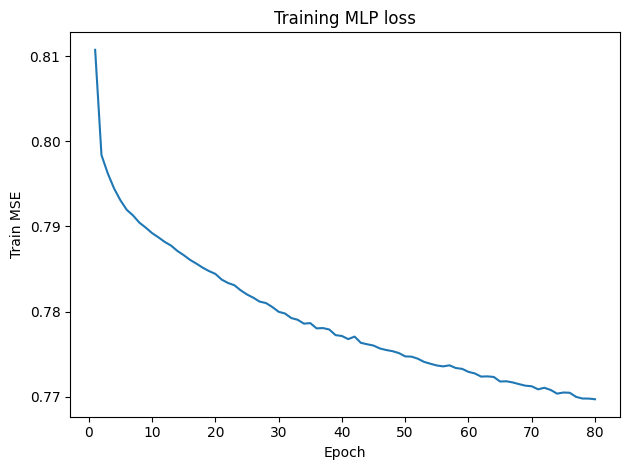

In [21]:
plt.figure()
plt.plot(range(1, epochs + 1), train_losses_mlp)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training MLP loss")
plt.tight_layout()
plt.show()

The sample_structs function generates new structures from a chosen condition value.

It:
*  sets both the flow (model) and the latent regressor (mlp) to eval mode
*  creates a batch filled with the requested normalized condition c_norm
*  uses the MLP to predict a latent vector z_pred for that condition
*  runs the flow inverse to map z_pred back to normalized coordinates
*  un-normalizes and reshapes the result to (n_samples, 1894, 3) and returns it as a NumPy array

In [22]:
def sample_structs(c_norm, n_samples=1):

    model.eval()
    mlp.eval()

    with torch.no_grad():

        c_batch = torch.full(
            (n_samples, 1),
            fill_value=float(c_norm),
            dtype=torch.float32,
            device=device,
        )

        z_pred = mlp(c_batch)
        x_norm, _ = model.inverse(z_pred)

        x_mean_dev = x_mean.to(device)
        x_std_dev  = x_std.to(device)

        x = x_norm * x_std_dev + x_mean_dev
        x = x.view(n_samples, 1894, 3)
        x_np = x.cpu().numpy()

    return x_np


This function uses OpenMM to energy-minimize a set of coordinates.

It loads the AMBER topology/restart files, sets the input coordinates as the starting structure, runs minimization, then returns the minimized coordinates plus the initial/final energies.

In [28]:
def minimize_coords_with_openmm(
    coords,
    top_file,
    rst_file,
    n_atoms_keep=1894,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,  # "CUDA", "OpenCL", "CPU"
):


    coords = np.asarray(coords)
    if tolerance is None:
        tolerance = 10.0 * unit.kilojoules_per_mole / unit.nanometer


    structure = pmd.load_file(top_file, rst_file)[:n_atoms_keep]
    system = structure.createSystem(
        nonbondedMethod=app.CutoffNonPeriodic,
        nonbondedCutoff=1.2 * unit.nanometer,
        constraints=None,
        implicitSolvent=app.OBC2 if use_gb else None,
    )


    topology = structure.topology
    integrator = openmm.VerletIntegrator(1.0 * unit.femtoseconds)



    if platform_name is not None:
        platform = openmm.Platform.getPlatformByName(platform_name)
        simulation = app.Simulation(topology, system, integrator, platform)
    else:
        simulation = app.Simulation(topology, system, integrator)
        platform = simulation.context.getPlatform()


    coords_nm = coords[0] * 0.1
    simulation.context.setPositions(coords_nm)


    t0 = time.perf_counter()
    simulation.minimizeEnergy(tolerance=tolerance, maxIterations=max_iterations)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    print(f"Minimization finished in {elapsed:.2f} s")


    state = simulation.context.getState(getPositions=True, getEnergy=True)
    E_final = state.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)
    print(f"Final potential energy: {E_final:.2f} kcal/mol")


    positions_nm = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    coords_min_angs = np.array(positions_nm) * 10.0
    coords_min_angs = coords_min_angs[np.newaxis, ...]

    return coords_min_angs, E_final, elapsed

This function saves a generated structure to a PDB file.

It takes the generated coordinates, optionally relaxes/minimizes them with OpenMM, then loads the AMBER topology/restart, trims to the DNA atoms, replaces the coordinates, and writes the result to out_file.

In [29]:
def save_generated_pdb(
    coords,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="generated_sample.pdb",
    relax=False,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,
):

    coords = np.asarray(coords)
    if relax:
        print("Running OpenMM minimization")
        coords_relaxed, E_final, elapsed = minimize_coords_with_openmm(
            coords=coords,
            top_file=topology_file,
            rst_file=rst_file,
            n_atoms_keep=n_atoms_keep,
            use_gb=use_gb,
            max_iterations=max_iterations,
            tolerance=tolerance,
            platform_name=platform_name,
        )
        coords_to_save = coords_relaxed

    else:
        coords_to_save = coords
        print("Skipping minimization; saving raw generated coordinates.")

    full = pmd.load_file(topology_file, rst_file)
    trimmed = full[:n_atoms_keep]
    trimmed.coordinates = coords_to_save[0]
    os.makedirs(os.path.dirname(out_file) or ".", exist_ok=True)
    trimmed.save(out_file, overwrite=True)


    return trimmed

Here we generate a new DNA sample from the trained flow at a chosen condition value, select one of the generated structures, reshape it to the expected (1, 1894, 3) format, and then save it as a PDB file. Before saving, we set relax=True so the structure is energy-minimized in OpenMM (with implicit solvent/GB) using the OpenCL platform.

In [30]:
def distance_to_norm(d_raw):
    return float((d_raw - c_mean.item()) / c_std.item())

In [31]:
c_norm = distance_to_norm(d_raw=120)
coords_gen = sample_structs(c_norm=c_norm, n_samples=1)[0]
coords_gen = coords_gen[np.newaxis, ...]

In [32]:
pdb_struct = save_generated_pdb(
    coords=coords_gen,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="mlp_seq_120_relaxed_2.pdb",
    relax=True,
    use_gb=True,
    max_iterations=500,
    platform_name="OpenCL",
)

Running OpenMM minimization
Minimization finished in 0.25 s
Final potential energy: -17586.24 kcal/mol
